In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from utils import *

# Correct vs Not for Conditioned vs Not

In [2]:
# Load all AIME experiments
experiments = {
    'aim_1': 'experiments/aim_1_20251113_025853/experiment.json',
    'aim_1c': 'experiments/aim_1c_20251113_025929/experiment.json',
    'aim_2': 'experiments/aim_2_20251113_130200/experiment.json',
    'aim_2c': 'experiments/aim_2c_20251113_072608/experiment.json',
    'aim_3': 'experiments/aim_3_20251113_025935/experiment.json',
    'aim_3c': 'experiments/aim_3c_20251113_081324/experiment.json',
}

def count_correct_rollouts(exp_path):
    with open(exp_path) as f:
        data = json.load(f)
    
    total = 0
    correct = 0
    for problem_key in data['results']:
        for rollout in data['results'][problem_key]['rollouts']:
            total += 1
            if rollout['is_correct']:
                correct += 1
    return correct, total

# Analyze each experiment
results = {}
for name, path in experiments.items():
    correct, total = count_correct_rollouts(path)
    results[name] = {'correct': correct, 'total': total}
    print(f"{name}: {correct}/{total} correct ({100*correct/total:.1f}%)")


aim_1: 89/500 correct (17.8%)
aim_1c: 446/500 correct (89.2%)
aim_2: 22/500 correct (4.4%)
aim_2c: 475/500 correct (95.0%)
aim_3: 13/500 correct (2.6%)
aim_3c: 426/500 correct (85.2%)


In [5]:
# Aggregate by condition and create dataframe
import pandas as pd

not_conditioned = [results['aim_1'], results['aim_2'], results['aim_3']]
conditioned = [results['aim_1c'], results['aim_2c'], results['aim_3c']]

nc_correct = sum(r['correct'] for r in not_conditioned)
nc_total = sum(r['total'] for r in not_conditioned)

c_correct = sum(r['correct'] for r in conditioned)
c_total = sum(r['total'] for r in conditioned)

df = pd.DataFrame([
    {'Condition': 'Not Conditioned', 'Correct': nc_correct, 'Total': nc_total, 'Accuracy (%)': 100 * nc_correct / nc_total},
    {'Condition': 'Conditioned', 'Correct': c_correct, 'Total': c_total, 'Accuracy (%)': 100 * c_correct / c_total},
])

df

,Condition,Correct,Total,Accuracy (%)
0,Not Conditioned,124,1500,8.266667
1,Conditioned,1347,1500,89.800000


# Difference between Prob Distributions for Entropies of Successful vs Unsuccessful Rollouts

In [18]:
x = [1,2,3,4,5]
np.array(x).cumsum(), np.sum(x) / len(x)

(array([ 1,  3,  6, 10, 15]), np.float64(3.0))

In [8]:
# Load experiment results
experiment_id = 'aim_1_20251113_025853'
with open(f'experiments/{experiment_id}/experiment.json', 'r') as f:
    experiment = json.load(f)

# Find problem key
problem_idx = 0
problem_key = next(k for k in experiment['results'] if experiment['results'][k]['dataset_index'] == problem_idx)
num_rollouts = len(experiment['results'][problem_key]['rollouts'])

print(f"Loaded experiment with {num_rollouts} rollouts for problem {problem_idx}")

Loaded experiment with 50 rollouts for problem 0


In [10]:
# Load all rollouts and compute metrics
rollout_data = []
for rollout_num in range(num_rollouts):
    with open(f'experiments/{experiment_id}/problem_{problem_idx}/rollout_{rollout_num}/graph_structure.json', 'r') as f:
        data = json.load(f)
    
    entropy = np.array([item['metric_value'] for item in data['final_sequence']])
    is_correct = experiment['results'][problem_key]['rollouts'][rollout_num]['is_correct']
    
    rollout_data.append({
        'rollout_num': rollout_num,
        'entropy': entropy,
        'is_correct': is_correct,
    })

print("Computed all metrics for all rollouts")
print(f"Total rollouts: {len(rollout_data)}")
print(f"Correct: {sum(1 for r in rollout_data if r['is_correct'])}")
print(f"Wrong: {sum(1 for r in rollout_data if not r['is_correct'])}")

Computed all metrics for all rollouts
Total rollouts: 50
Correct: 22
Wrong: 28


In [12]:
rollout_data[0]['entropy']

array([4.37500000e-01, 7.61718750e-01, 4.96093750e-01, ...,
       1.23977661e-04, 7.05718994e-05, 1.25885010e-04], shape=(1031,))

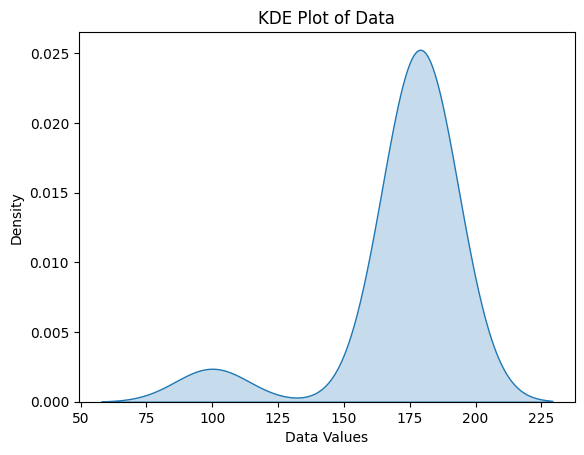

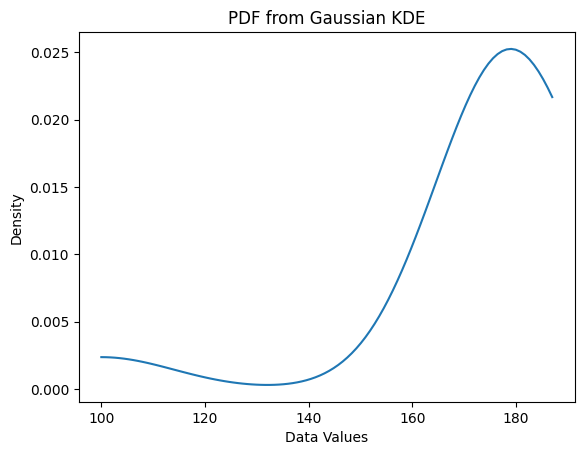

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Sample data
data = np.random.normal(loc=0, scale=1, size=1000)
data = np.array([100, 173, 175, 177, 177.5, 178.5, 179, 179.5, 180, 181, 182, 187])

# Using Seaborn's kdeplot for visualization
sns.kdeplot(data, fill=True)
plt.xlabel("Data Values")
plt.ylabel("Density")
plt.title("KDE Plot of Data")
plt.show()

# Using scipy.stats.gaussian_kde for programmatic access to the PDF
kde = gaussian_kde(data)
x_values = np.linspace(min(data), max(data), 100)
pdf_values = kde(x_values)

plt.plot(x_values, pdf_values)
plt.xlabel("Data Values")
plt.ylabel("Density")
plt.title("PDF from Gaussian KDE")
plt.show()